# Tests Unitarios
---

## Concepto

* Son tests que se enfocan en **verificar el correcto funcionamiento de la unidad más pequeña de código**, generalmente una **función, método o clase**, de manera aislada del resto del sistema
* El resultado de la prueba puede ser **PASS** o **FAIL**
* **Objetivo principal**: detectar errores o comportamientos inesperados en cada unidad de forma temprana, antes de integrarla con otras partes del programa

## Utilidad

* **Detectar errores de manera temprana:** al probar unidades individuales, los fallos se localizan fácilmente
* **Garantizar la calidad del código:** ayudan a mantener un código confiable y robusto
* **Facilitar cambios y refactorización:** si se modifica el código, los tests aseguran que nada se rompa
* **Documentar el comportamiento esperado:** cada test funciona como ejemplo de cómo debería funcionar la unidad
* **Reducir costos de mantenimiento:** corregir errores tempranamente evita problemas mayores en producción

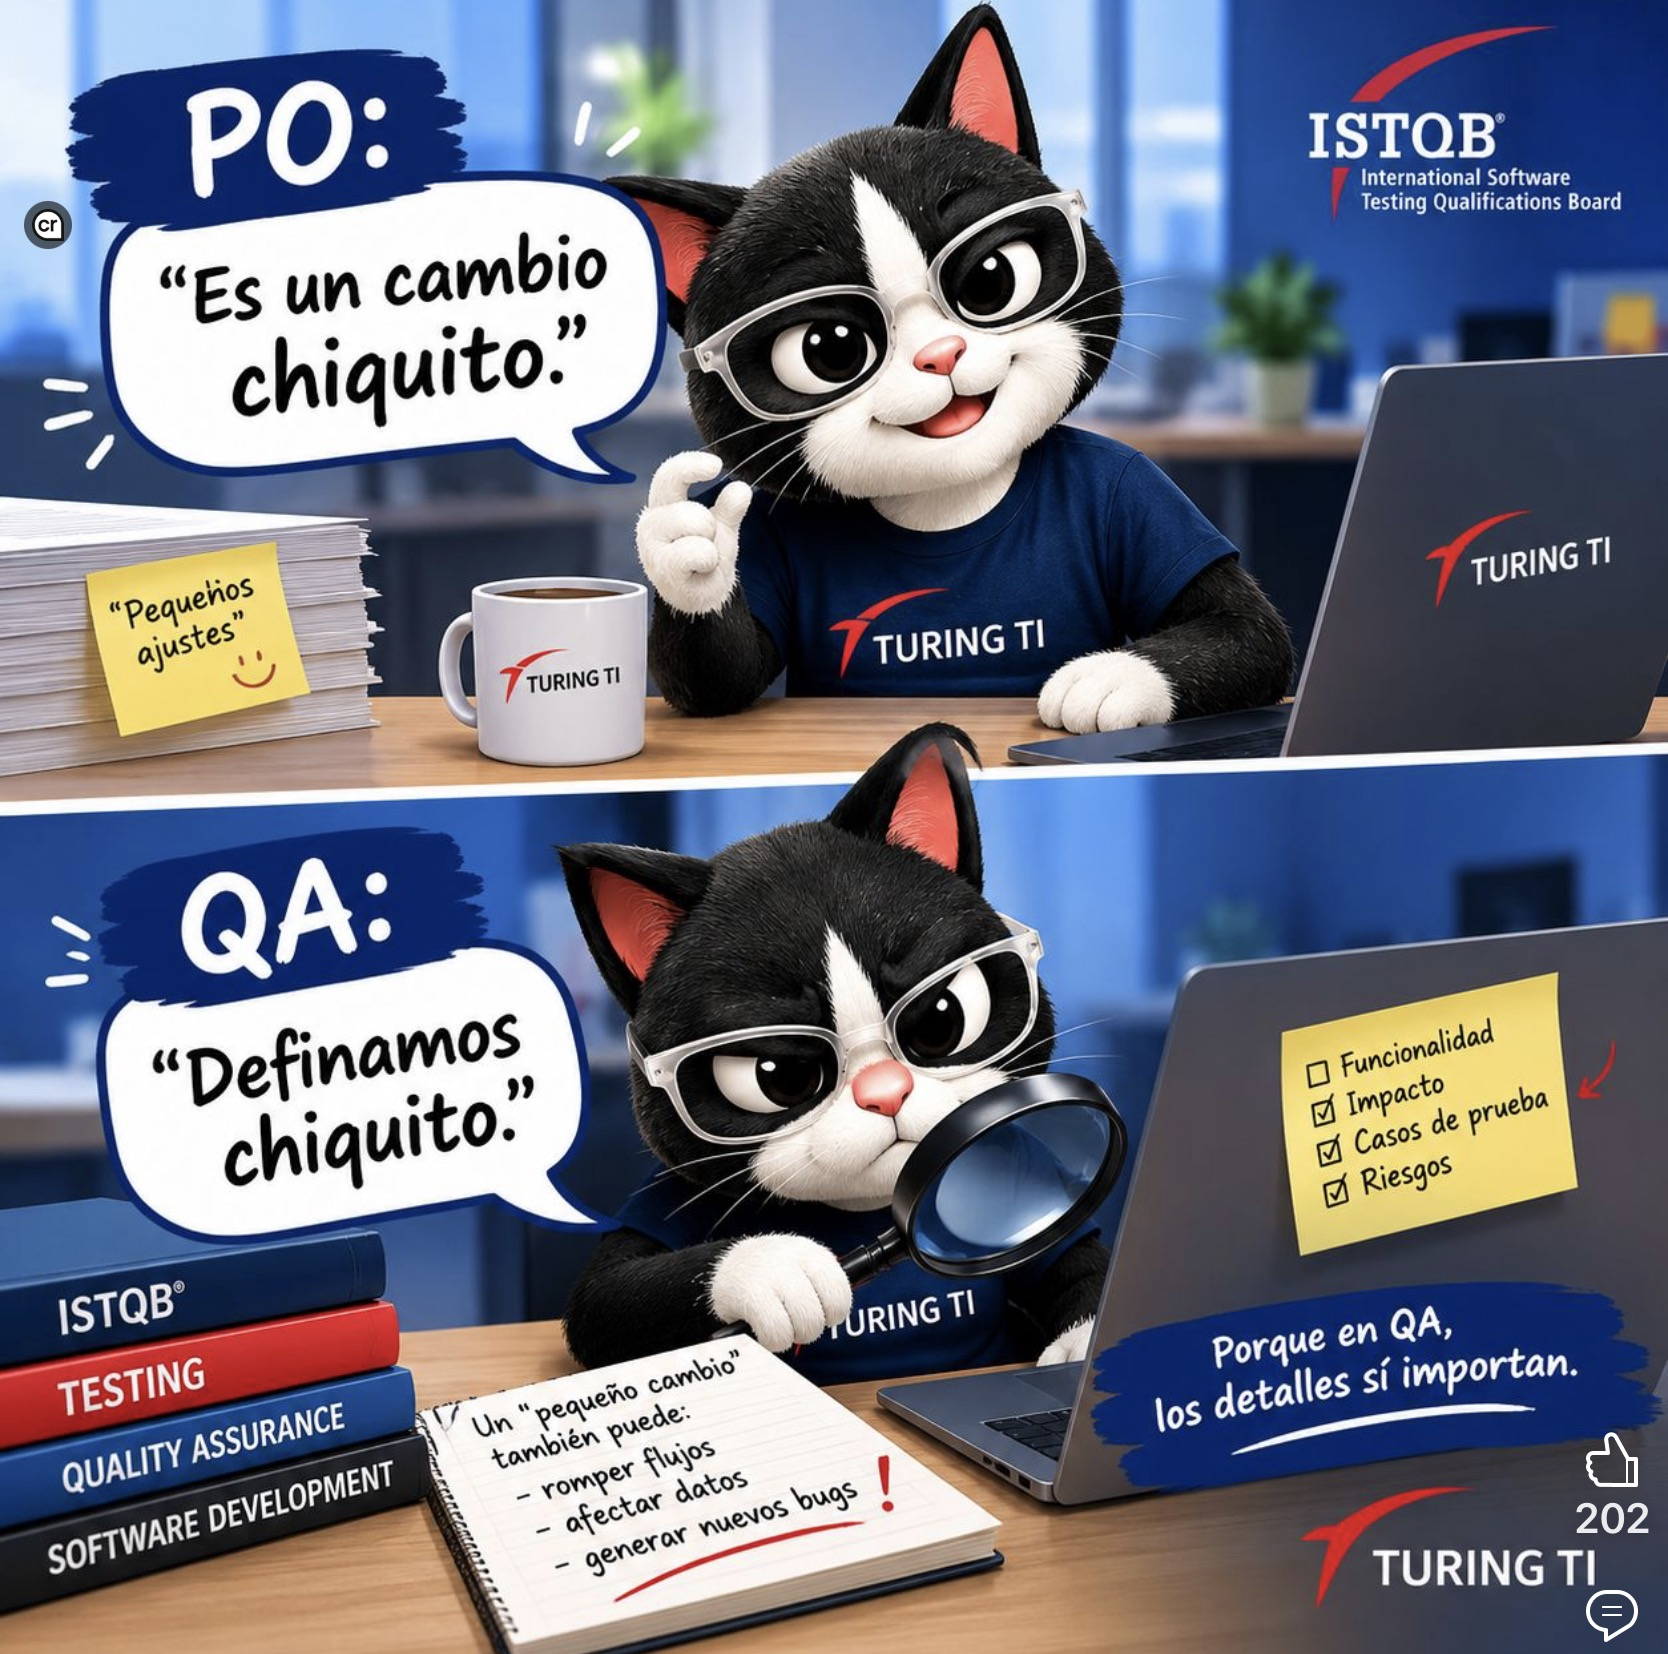

## Características

* **Aislamiento**: un unit test debe probar únicamente una unidad de código, sin depender de bases de datos, APIs externas, archivos u otros módulos. La idea es evaluar la función por sí sola, sin influencias externas
* **Determinismo**: el resultado del test debe ser siempre el mismo, sin importar cuántas veces se ejecute o en qué entorno se corra. No debe depender de valores variables como la hora del sistema, la red o datos aleatorios sin control
* **Rapidez**: los tests unitarios deben ejecutarse en milisegundos. Como se corren constantemente durante el desarrollo, deben ser livianos y eficientes
* **Simplicidad**: cada test debe enfocarse en un solo comportamiento específico. No debe intentar validar muchos escenarios dentro del mismo bloque, ya que eso dificulta su lectura y mantenimiento
* **Repetibilidad**: un test unitario debe poder ejecutarse en cualquier momento sin configuraciones adicionales. No debería requerir que el desarrollador prepare datos manualmente ni que el entorno tenga configuraciones especiales
* **Independencia**: los tests no deben depender unos de otros. Cada uno debe poder ejecutarse por separado, sin necesidad de que otro test se ejecute antes o después
* **Legibilidad**: los tests deben ser claros y fáciles de entender. Su nombre y contenido deben indicar exactamente qué comportamiento están verificando. De esta manera, también funcionan como documentación del sistema

## Ventajas de hacer tests unitarios con Python

1. Menos código, menos estructura obligatoria, y mucho más legible
2. Mocking integrado: no se necesita instalar nada extra para empezar a hacer pruebas y crear mocks
3. Velocidad sin compilación
4. Ecosistema estable (pytest)
5. Curva de aprendizaje
6. Configuración inicial baja

## Tests Unitarios con Unittest

### Ejemplos de Pruebas Funcionales 

* Verifican que una **función o método cumpla con su comportamiento esperado** según la especificación

In [1]:
class Matematicas:

  @staticmethod
  def sumar(op1, op2):
    return op1 + op2

In [2]:
import unittest

class SumadorTest(unittest.TestCase):

  def test_suma_1_y_2(self):
    self.assertEqual(3, Matematicas.sumar(1, 2))
    
  def test_suma_2_y_2(self):
    self.assertEqual(5, Matematicas.sumar(2, 2))

In [3]:
unittest.main(defaultTest='SumadorTest', argv=[''], verbosity=2, exit=False)

test_suma_1_y_2 (__main__.SumadorTest.test_suma_1_y_2) ... ok
test_suma_2_y_2 (__main__.SumadorTest.test_suma_2_y_2) ... FAIL

FAIL: test_suma_2_y_2 (__main__.SumadorTest.test_suma_2_y_2)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/var/folders/0n/g5l4v8c52nn4wxk7hl89vk3m0000gn/T/ipykernel_19940/2817879563.py", line 9, in test_suma_2_y_2
    self.assertEqual(5, Matematicas.sumar(2, 2))
AssertionError: 5 != 4

----------------------------------------------------------------------
Ran 2 tests in 0.006s

FAILED (failures=1)


### Métodos de unittest.TestCase

|                                         |                                                    |
| --                                      | --                                                 |
| self.assertEqual(a, b)                  | comprueba que a == b                               |
| self.assertNotEqual(a, b)               | comprueba que a != b                               |
| self.assertTrue(expr)                   | comprueba que la expresión sea True                |
| self.assertFalse(expr)                  | comprueba que la expresión sea False               |
| self.assertRaises(Error, funcion, args) | comprueba que se lance una excepción               |

### Ejemplos de Pruebas de Excepciones o Errores

* Se enfocan en comprobar que el código **maneje correctamente situaciones excepcionales**

In [1]:
def dividir(a, b):
    if b == 0:
        raise ValueError("No se puede dividir por cero")
    return a / b

In [6]:
import unittest

class TestExcepciones(unittest.TestCase):
    
    def test_dividir_por_cero(self):
        with self.assertRaises(ValueError):
            dividir(10, 0)

    def test_division_ok(self):
        self.assertEqual(2, dividir(10, 5))

In [7]:
unittest.main(defaultTest='TestExcepciones', argv=[''], verbosity=2, exit=False)

test_dividir_por_cero (__main__.TestExcepciones.test_dividir_por_cero) ... ok
test_division_ok (__main__.TestExcepciones.test_division_ok) ... ok

----------------------------------------------------------------------
Ran 2 tests in 0.006s

OK


In [8]:
class CuentaBancaria:
    
    def __init__(self, saldo_inicial=0):
        self.__saldo = saldo_inicial

    def get_saldo(self):
        return self.__saldo
    
    def depositar(self, monto):
        self.__saldo += monto

    def retirar(self, monto):
        if monto > self.__saldo:
            raise ValueError("Fondos insuficientes")
        self.__saldo -= monto

In [15]:
import unittest

class TestCuentaBancaria(unittest.TestCase):

    def test_consultar_recien_creada(self):
        self.assertEqual(100, CuentaBancaria(100).get_saldo())
    
    def test_depositar(self):
        cuenta = CuentaBancaria(100)
        cuenta.depositar(50)
        self.assertEqual(150, cuenta.get_saldo())

    def test_retiro(self):
        cuenta = CuentaBancaria(100)
        cuenta.retirar(40)
        self.assertEqual(60, cuenta.get_saldo())

    def test_retiro_invalido(self):
        cuenta = CuentaBancaria(100)
        with self.assertRaises(ValueError):
            cuenta.retirar(120)

In [16]:
unittest.main(defaultTest='TestCuentaBancaria', argv=[''], verbosity=2, exit=False)

test_consultar_recien_creada (__main__.TestCuentaBancaria.test_consultar_recien_creada) ... ok
test_depositar (__main__.TestCuentaBancaria.test_depositar) ... ok
test_retiro (__main__.TestCuentaBancaria.test_retiro) ... ok
test_retiro_invalido (__main__.TestCuentaBancaria.test_retiro_invalido) ... ok

----------------------------------------------------------------------
Ran 4 tests in 0.014s

OK


### Ejemplos de Pruebas de Límite (Boundary Testing)

* Se centran en verificar el comportamiento del código en **valores límite o extremos**

In [19]:
def es_edad_valida(edad):
    return 0 <= edad <= 120

In [20]:
import unittest

class TestLimite(unittest.TestCase):
    
    def test_edad_limite_0(self):
        self.assertTrue(es_edad_valida(0))
    
    def test_edad_limite_120(self):
        self.assertTrue(es_edad_valida(120))

    def test_edad_limite_menos_1(self):
        self.assertFalse(es_edad_valida(-1))

    def test_edad_limite_121(self):
        self.assertFalse(es_edad_valida(121))

In [21]:
unittest.main(defaultTest='TestLimite', argv=[''], verbosity=2, exit=False)

test_edad_limite_0 (__main__.TestLimite.test_edad_limite_0) ... ok
test_edad_limite_120 (__main__.TestLimite.test_edad_limite_120) ... ok
test_edad_limite_121 (__main__.TestLimite.test_edad_limite_121) ... ok
test_edad_limite_menos_1 (__main__.TestLimite.test_edad_limite_menos_1) ... ok

----------------------------------------------------------------------
Ran 4 tests in 0.012s

OK


### Ejemplos de Pruebas de Estado

* Verifican cómo cambia el **estado interno de un objeto o clase** después de ejecutar una operación
* **Ejemplo**: un contador que aumenta su valor cada vez que se llama al método `incrementar_en_1()`

In [24]:
class Contador:
    
    def __init__(self):
        self.__valor = 0

    def get_valor(self):
        return self.__valor
        
    def incrementar_en_1(self):
        self.__valor += 1

In [27]:
import unittest

class TestEstado(unittest.TestCase):
    
    def test_incrementar_una_vez(self):
        c = Contador()
        c.incrementar_en_1()
        self.assertEqual(1, c.get_valor())
    
    def test_incrementar_dos_veces(self):
        c = Contador()
        c.incrementar_en_1()
        c.incrementar_en_1()
        self.assertEqual(2, c.get_valor())

In [29]:
unittest.main(defaultTest='TestEstado', argv=[''], verbosity=2, exit=False)

test_incrementar_dos_veces (__main__.TestEstado.test_incrementar_dos_veces) ... ok
test_incrementar_una_vez (__main__.TestEstado.test_incrementar_una_vez) ... ok

----------------------------------------------------------------------
Ran 2 tests in 0.005s

OK


### Ejemplos de Pruebas de Mocking / Dependencias

* Se usan **objetos simulados (mocks, stubs)** para aislar la unidad de sus dependencias externas
* **Ejemplo**: probar un método que envía correos sin realmente enviar emails, usando un objeto simulado

In [30]:
class Correo:
    
    def enviar(self, mensaje):
        pass

In [32]:
class Usuario:
    
    def __init__(self, correo):
        self.__correo = correo
        
    def notificar(self, mensaje):
        self.__correo.enviar(mensaje)

In [38]:
import unittest
from unittest.mock import Mock

class TestMocking(unittest.TestCase):
    
    def test_notificar(self):
        correo_mock = Mock()
        usuario = Usuario(correo_mock)
        usuario.notificar('Hola')
        correo_mock.enviar.assert_called_with('Hola')
        # assert_called_with es un método que tienen los objetos Mock() 
        # para verificar con qué argumentos fue llamado por última vez el mock.
        # Si el mock no fue llamado con esos argumentos exactos (la última vez), el assert lanza una excepción (AssertionError) 
        # y el test falla.

In [39]:
unittest.main(defaultTest='TestMocking', argv=[''], verbosity=2, exit=False)

test_notificar (__main__.TestMocking.test_notificar) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.007s

OK


### Ejemplos de Pruebas Parametrizadas

* Permiten **probar la misma función con múltiples conjuntos de datos** automáticamente
* **Ejemplo**: probar la función `esPar(n)` con una lista de números positivos, negativos y cero

In [44]:
def es_par(n):
    return n % 2 == 0

In [45]:
import unittest

class TestParametrizadas1(unittest.TestCase):

    def test_valor_4(self):
        self.assertEqual(True, es_par(4))

    def test_valor_3(self):
        self.assertEqual(False, es_par(3))

    def test_valor_5(self):
        self.assertEqual(False, es_par(5))

In [46]:
unittest.main(defaultTest='TestParametrizadas1', argv=[''], verbosity=2, exit=False)

test_valor_3 (__main__.TestParametrizadas1.test_valor_3) ... ok
test_valor_4 (__main__.TestParametrizadas1.test_valor_4) ... ok
test_valor_5 (__main__.TestParametrizadas1.test_valor_5) ... ok

----------------------------------------------------------------------
Ran 3 tests in 0.017s

OK


In [48]:
import unittest

class TestParametrizadas2(unittest.TestCase):
    
    def test_varios_valores(self):
        casos = [(2, True), (3, True), (0, True), (-4, True), (-5, False)]
        for valor, esperado in casos:
            with self.subTest(valor=valor):
                self.assertEqual(esperado, es_par(valor))

In [49]:
unittest.main(defaultTest='TestParametrizadas2', argv=[''], verbosity=2, exit=False)

test_varios_valores (__main__.TestParametrizadas2.test_varios_valores) ... 
  test_varios_valores (__main__.TestParametrizadas2.test_varios_valores) (valor=3) ... FAIL

FAIL: test_varios_valores (__main__.TestParametrizadas2.test_varios_valores) (valor=3)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/var/folders/0n/g5l4v8c52nn4wxk7hl89vk3m0000gn/T/ipykernel_4226/4024720632.py", line 9, in test_varios_valores
    self.assertEqual(esperado, es_par(valor))
AssertionError: True != False

----------------------------------------------------------------------
Ran 1 test in 0.004s

FAILED (failures=1)


## Herramientas y Frameworks de Pruebas en Python

| Herramienta / Framework       | Tipo de pruebas que soporta                            | Ventajas principales                                               |
|--                             | --                                                     | --                                                                 |
| **unittest**                  | Unitarias, integración, mocking                        | Incluido en Python, basado en clases, estable                      | 
| **pytest**                    | Unitarias, integración, parametrizadas, fixtures       | Sintaxis simple, flexible, extensible con plugins                  |
| **nose2**                     | Unitarias, integración                                 | Detecta tests automáticamente, evolución de nose                   |
| **doctest**                   | Unitarias simples dentro de docstrings                 | Permite documentación + pruebas en un mismo lugar                  |
| **Hypothesis**                | Pruebas basadas en propiedades                         | Genera automáticamente muchos casos, encuentra errores inesperados |
| **Coverage**                  | Análisis de cobertura de código                        | Mide qué porcentaje del código está cubierto por tests             |

## Tests Unitarios con Pytest
---

* Es un framework de prueba unitario para Python
* Más simple de usar y eficiente que unittest
* Instalación: pip install pytest

| Comandos                   |                                        |
| --                         | --                                     |
| pytest --version           | muestra versión                        |
| pytest modulo.py           | ejecuta funciones con test_* or *_test |
| pytest modulo.py::test_xxx | ejecuta la función test_xxx            |
| pytest -s                  | muestra los prints                     |
| pytest -h                  | muestra la ayuda                       |

### Tests básicos

In [50]:
%%file unit/p01.py
import pytest

def test_01():
    assert True

def test_02():
    assert False

def test_03():
    assert (1, 2, 3) == (1, 2, 3)

Overwriting unit/p01.py


In [51]:
!pytest unit/p01.py

============================= test session starts ==============================
platform darwin -- Python 3.12.7, pytest-7.4.4, pluggy-1.0.0
rootdir: /Users/ppando/Materias/qa/doc
plugins: allure-pytest-2.16.0, Faker-37.3.0, mock-3.14.1, typeguard-4.4.4, anyio-4.2.0
collected 3 items                                                              

unit/p01.py .F.                                                          [100%]

=================================== FAILURES ===================================
___________________________________ test_02 ____________________________________

    def test_02():
>       assert False
E       assert False

unit/p01.py:7: AssertionError
=========================== short test summary info ============================
FAILED unit/p01.py::test_02 - assert False
========================= 1 failed, 2 passed in 0.20s ==========================


In [60]:
%%file unit/p02.py
import pytest

def increment_one(numero):
    return numero + 1

def test_increment():
    assert increment_one(1) == 2

Overwriting unit/p02.py


In [61]:
!pytest unit/p02.py

============================= test session starts ==============================
platform darwin -- Python 3.12.7, pytest-7.4.4, pluggy-1.0.0
rootdir: /Users/ppando/Materias/qa/doc
plugins: allure-pytest-2.16.0, Faker-37.3.0, mock-3.14.1, typeguard-4.4.4, anyio-4.2.0
collected 1 item                                                               

unit/p02.py .                                                            [100%]

============================== 1 passed in 0.08s ===============================


In [62]:
%%file unit/p03.py
import pytest

def make_a_dict(a, b):
    operation = a + b
    return {'a': a, 'b': b, 'result': operation}

def test_make_a_dict():
    actual = make_a_dict(2, 3)
    expected = {'a': 2, 'b': 3, 'result': 5}
    assert actual == expected

Overwriting unit/p03.py


In [63]:
!pytest unit/p03.py

============================= test session starts ==============================
platform darwin -- Python 3.12.7, pytest-7.4.4, pluggy-1.0.0
rootdir: /Users/ppando/Materias/qa/doc
plugins: allure-pytest-2.16.0, Faker-37.3.0, mock-3.14.1, typeguard-4.4.4, anyio-4.2.0
collected 1 item                                                               

unit/p03.py .                                                            [100%]

============================== 1 passed in 0.10s ===============================


### Filtering

* Se pone cualquier nombre de marca
* Se ejecuta con pytest -m \<nombre de marca> -vv

In [28]:
%%file unit/p04.py
import pytest

@pytest.mark.finished
def test_01():
    assert True

@pytest.mark.unfinished
def test_02():
    assert False

def test_03():
    assert (1, 2, 3) == (1, 2, 3)

Overwriting unit/p04.py


In [29]:
!pytest -m finished unit/p04.py

============================= test session starts ==============================
platform darwin -- Python 3.12.7, pytest-7.4.4, pluggy-1.0.0
rootdir: /Users/ppando/Materias/qa/doc
plugins: allure-pytest-2.16.0, Faker-37.3.0, mock-3.14.1, typeguard-4.4.4, anyio-4.2.0
collected 3 items / 2 deselected / 1 selected                                  

unit/p04.py .                                                            [100%]

=============================== warnings summary ===============================
unit/p04.py:3
  /Users/ppando/Materias/qa/doc/unit/p04.py:3: PytestUnknownMarkWarning: Unknown pytest.mark.finished - is this a typo?  You can register custom marks to avoid this warning - for details, see https://docs.pytest.org/en/stable/how-to/mark.html
    @pytest.mark.finished

unit/p04.py:7
  /Users/ppando/Materias/qa/doc/unit/p04.py:7: PytestUnknownMarkWarning: Unknown pytest.mark.unfinished - is this a typo?  You can register custom marks to avoid this warning - for details, s

### Skip

In [64]:
%%file unit/p05.py
import pytest

@pytest.mark.skip('api fuera de fecha')
def test_connect():
    pass

Overwriting unit/p05.py


In [65]:
!pytest unit/p05.py

============================= test session starts ==============================
platform darwin -- Python 3.12.7, pytest-7.4.4, pluggy-1.0.0
rootdir: /Users/ppando/Materias/qa/doc
plugins: allure-pytest-2.16.0, Faker-37.3.0, mock-3.14.1, typeguard-4.4.4, anyio-4.2.0
collected 1 item                                                               

unit/p05.py s                                                            [100%]

============================== 1 skipped in 0.02s ==============================


### Parametrize

* Permite ejecutar un mismo test con distintos datos
* Ayuda a no repetir el codigo muchas veces
* Esto elimina el código repetitivo al generar automáticamente casos de prueba distintos y aislados para cada conjunto de entrada

In [68]:
%%file unit/p06.py
import pytest

@pytest.mark.parametrize("number", [1, 2, -1, 3])
def test_is_positive(number):
    assert number > 0

Overwriting unit/p06.py


In [69]:
!pytest unit/p06.py

============================= test session starts ==============================
platform darwin -- Python 3.12.7, pytest-7.4.4, pluggy-1.0.0
rootdir: /Users/ppando/Materias/qa/doc
plugins: allure-pytest-2.16.0, Faker-37.3.0, mock-3.14.1, typeguard-4.4.4, anyio-4.2.0
collected 4 items                                                              

unit/p06.py ..F.                                                         [100%]

=================================== FAILURES ===================================
_____________________________ test_is_positive[-1] _____________________________

number = -1

    @pytest.mark.parametrize("number", [1, 2, -1, 3])
    def test_is_positive(number):
>       assert number > 0
E       assert -1 > 0

unit/p06.py:5: AssertionError
=========================== short test summary info ============================
FAILED unit/p06.py::test_is_positive[-1] - assert -1 > 0
========================= 1 failed, 3 passed in 0.15s ==========================


In [34]:
%%file unit/p07.py
import pytest

def add(a, b):
    return a + b

@pytest.mark.parametrize("a, b, expected", [
    (1, 2, 3),
    (5, 5, 10),
    (-1, 1, 0),
])
def test_add(a, b, expected):
    assert add(a, b) == expected

Overwriting unit/p07.py


In [35]:
!pytest unit/p07.py

============================= test session starts ==============================
platform darwin -- Python 3.12.7, pytest-7.4.4, pluggy-1.0.0
rootdir: /Users/ppando/Materias/qa/doc
plugins: allure-pytest-2.16.0, Faker-37.3.0, mock-3.14.1, typeguard-4.4.4, anyio-4.2.0
collected 3 items                                                              

unit/p07.py ...                                                          [100%]

============================== 3 passed in 0.06s ===============================


In [36]:
%%file unit/p08.py
import pytest

@pytest.mark.parametrize('passwd', ['123456', 'abcdefdfs', 'as52345fasdf4'])
def test_password_length(passwd):
    assert len(passwd) >= 8

Overwriting unit/p08.py


In [37]:
!pytest unit/p08.py

============================= test session starts ==============================
platform darwin -- Python 3.12.7, pytest-7.4.4, pluggy-1.0.0
rootdir: /Users/ppando/Materias/qa/doc
plugins: allure-pytest-2.16.0, Faker-37.3.0, mock-3.14.1, typeguard-4.4.4, anyio-4.2.0
collected 3 items                                                              

unit/p08.py F..                                                          [100%]

=================================== FAILURES ===================================
_________________________ test_password_length[123456] _________________________

passwd = '123456'

    @pytest.mark.parametrize('passwd', ['123456', 'abcdefdfs', 'as52345fasdf4'])
    def test_password_length(passwd):
>       assert len(passwd) >= 8
E       AssertionError: assert 6 >= 8
E        +  where 6 = len('123456')

unit/p08.py:5: AssertionError
=========================== short test summary info ============================
FAILED unit/p08.py::test_password_length[123456] - 

In [38]:
%%file unit/p09.py
import pytest

def some_calculation(a, b):
    return a + b

@pytest.mark.parametrize('a, b, expected', [(1, 2, 3), (3, 3, 6), (3, -2, 1)])
def test_some_calculation(a, b, expected):
    assert some_calculation(a, b) == expected

Overwriting unit/p09.py


In [39]:
!pytest unit/p09.py

============================= test session starts ==============================
platform darwin -- Python 3.12.7, pytest-7.4.4, pluggy-1.0.0
rootdir: /Users/ppando/Materias/qa/doc
plugins: allure-pytest-2.16.0, Faker-37.3.0, mock-3.14.1, typeguard-4.4.4, anyio-4.2.0
collected 3 items                                                              

unit/p09.py ...                                                          [100%]

============================== 3 passed in 0.06s ===============================


### Fixture

In [40]:
%%file unit/p10.py
import pytest

@pytest.fixture()
def db():
    print('Connection successful')
    yield
    print('Connection closed')

def search_user(user_id):
    d = {'001': 'ppando', '002': 'otrouser'}
    return d[user_id]

def test_search(db):
    assert search_user('001') == 'ppando'

def test_search2(db):
    assert search_user('002') == 'otrouser'

Overwriting unit/p10.py


In [41]:
!pytest -s --setup-show unit/p10.py

============================= test session starts ==============================
platform darwin -- Python 3.12.7, pytest-7.4.4, pluggy-1.0.0
rootdir: /Users/ppando/Materias/qa/doc
plugins: allure-pytest-2.16.0, Faker-37.3.0, mock-3.14.1, typeguard-4.4.4, anyio-4.2.0
collected 2 items                                                              

unit/p10.py 
SETUP    S _session_fakerConnection successful

        SETUP    F db
        unit/p10.py::test_search (fixtures used: _session_faker, db, request).Connection closed

        TEARDOWN F dbConnection successful

        SETUP    F db
        unit/p10.py::test_search2 (fixtures used: _session_faker, db, request).Connection closed

        TEARDOWN F db
TEARDOWN S _session_faker

============================== 2 passed in 0.06s ===============================


### Pytest mock

* Es una libreria que permite mockear (engañar), sin ejecutar el código de la función
* Instalación: pip install pytest-mock

In [42]:
!pip install pytest-mock

In [43]:
%%file unit/p11.py
def some_calculation(a, b):
    return a + b

def test_some_calculation():
    assert some_calculation(1, 2) == 3

def make_a_dict(a, b):
    operation = some_calculation(a, b)
    return {"a": a, "b": b, "result": operation}

def test_make_a_dict(mocker):
    mocker.patch("p09.some_calculation", return_value=5, autospec=True)
    actual = make_a_dict(2, 3)
    expected = {"a": 2, "b": 3, "result": 5}
    assert actual == expected

Overwriting unit/p11.py


In [44]:
!pytest unit/p11.py

============================= test session starts ==============================
platform darwin -- Python 3.12.7, pytest-7.4.4, pluggy-1.0.0
rootdir: /Users/ppando/Materias/qa/doc
plugins: allure-pytest-2.16.0, Faker-37.3.0, mock-3.14.1, typeguard-4.4.4, anyio-4.2.0
collected 2 items                                                              

unit/p11.py ..                                                           [100%]

============================== 2 passed in 0.07s ===============================


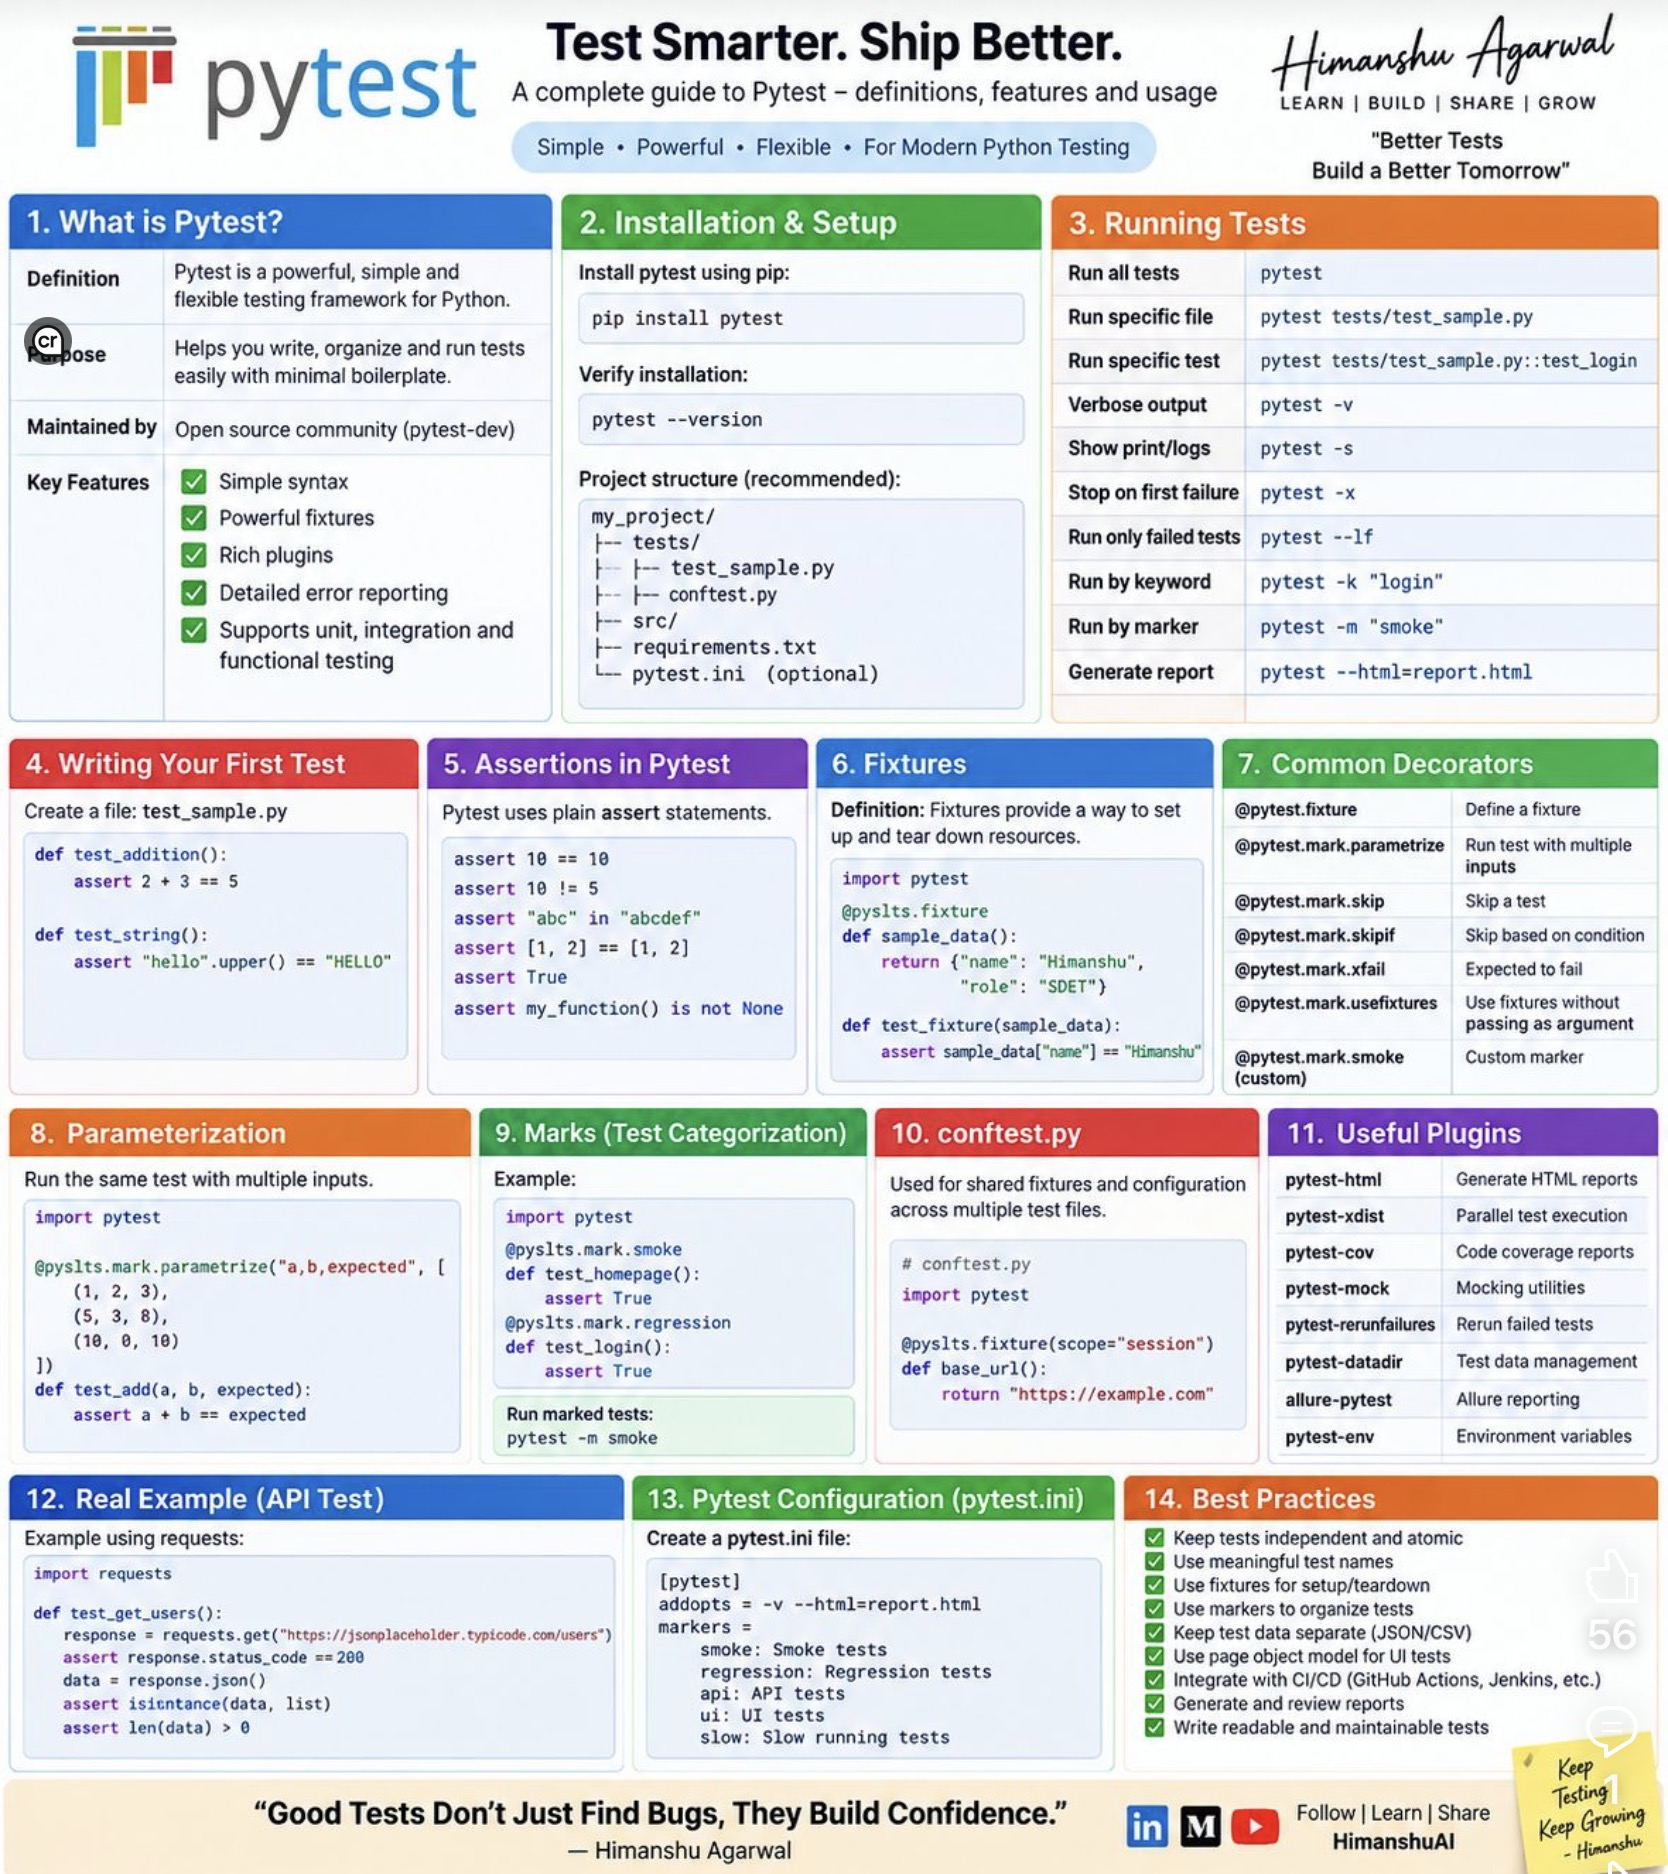

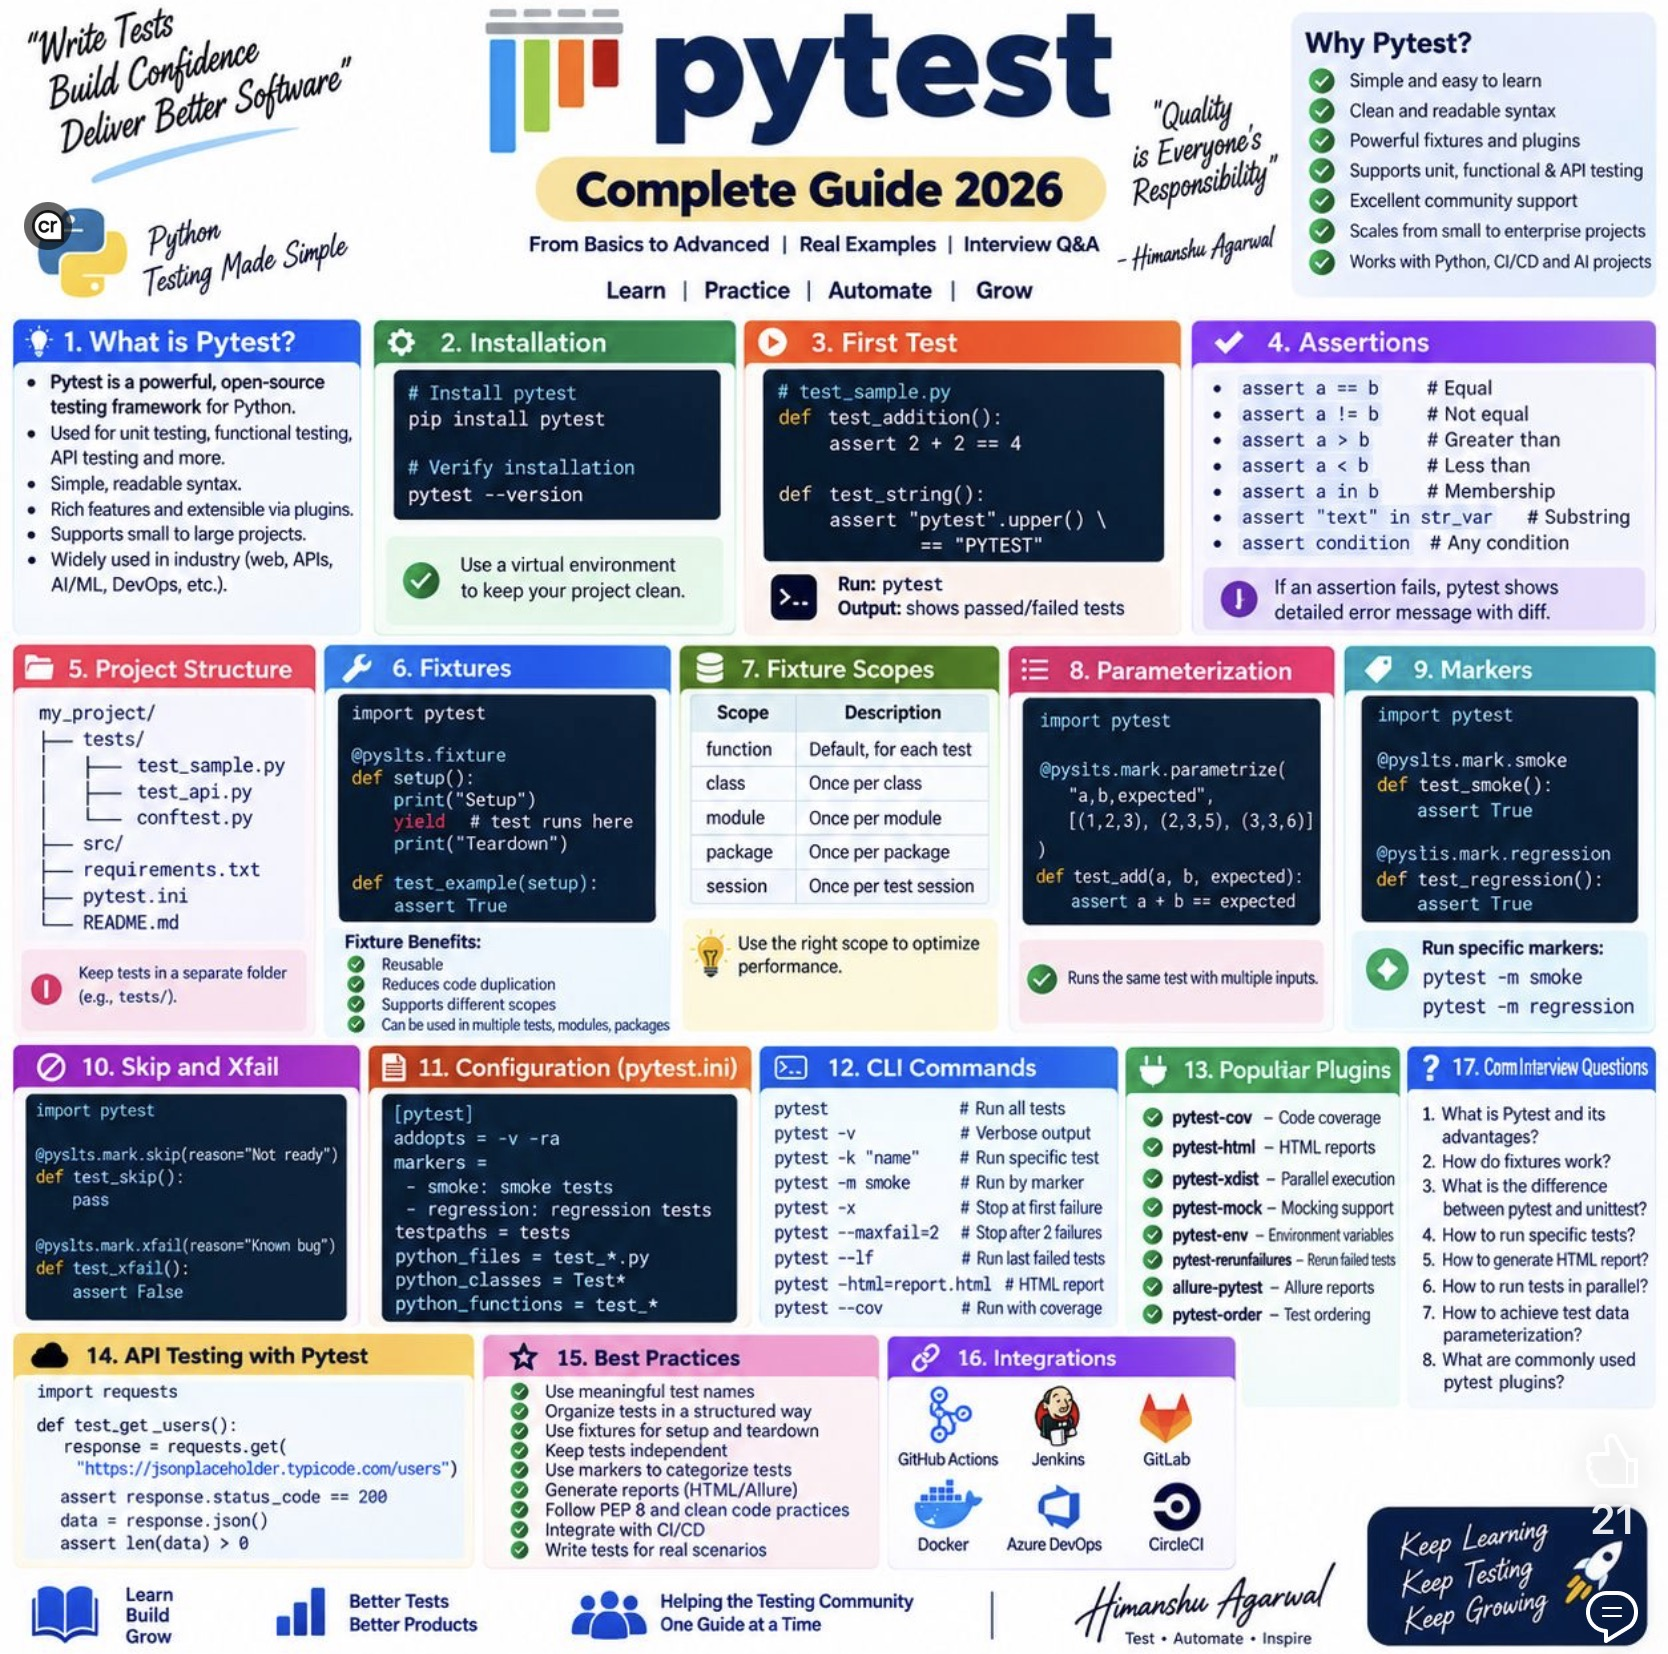